In [1]:


import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from analysis_of_simulation_result import * 

import numpy as np 
import pandas as pd 
import os 
import pickle
from cell_groups import *

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7
fontsize=7

In [71]:
from scipy.stats import hmean

DATA_DIR = REPO_ROOT/'figure5/data'

def load_screening_result(filename, sheet_name):
    df = pd.read_excel(
        DATA_DIR / filename,
        sheet_name=sheet_name,
        header=1,
        index_col=0,
    )

    if "type" in df.index:
        df = df.drop(index="type")

    df.index.name = "type"
    return df

def calculate_network_characteristics(activation,silence,mode='sweet'):
    
    df_per_concent = {}
    for concent in silence.columns:
        if mode == 'sweet':
            slnc = silence[concent]
            act = activation[0]
            N = (slnc.loc['control'] - slnc)/slnc.loc['control']
            S = act - act.loc['control']
        else:
            slnc = silence[concent]
            act = activation[concent]
            N = (slnc - slnc.loc['control'])/slnc.loc['control']
            S = (act.loc['control'] - act)/act.loc['control']
        N = N.clip(lower=0)
        S = S.clip(lower=0)
        N, S = N.align(S)
        HM = hmean(np.vstack([N,S]))
        df = pd.DataFrame({
            'Necessity': N,
            'Sufficiency': S,
            'HM': HM
        }, index=N.index)    
        df['rank'] = df['HM'].rank(ascending=False, method='min').astype(int)
        df_per_concent[concent] = df 
    
    return df_per_concent 



### Sweet ###
# Tarsal
tarsal_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "tarsal",
)
tarsal_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "tarsal",
)


# Labellar
labial_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "labellar",
)
labial_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "labellar",
)
labial_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "labellar",
)



### Sweet ###
# Tarsal
tarsal_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "labellar",
)
labial_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "labellar",
)
labial_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "labellar",
)




tarsal_sweet_df = calculate_network_characteristics(tarsal_activation_per,tarsal_screening_per,mode='sweet')
labial_sweet_df = calculate_network_characteristics(labial_activation_per,labial_screening_per,mode='sweet')
tarsal_geosmin_df = calculate_network_characteristics(tarsal_geosmin_activation_per,tarsal_geosmin_screening_per,mode='geosmin')
labial_geosmin_df = calculate_network_characteristics(labial_geosmin_activation_per,labial_geosmin_screening_per,mode='geosmin')


# color_path = REPO_ROOT/'figure6/figure6C,F,L,O_Compare_necessity_exp_vs_simul/data'
# color_info_sweet = {}
# for g in ['tarsal','labial']:
#     color_info_sweet[g] = pickle.load(open(os.path.join(color_path,f'color_info_{g}-core.pkl'),'rb'))
# Rank data to Set color of nodes 
from color_utils import get_graded_color
def make_rank_color_info(rank_df, top_n=20, base_color="#FF0066", default_color="#777777"):
    num_top_ranked = (rank_df <= top_n).sum(axis=1)

    return {
        tid: (
            get_graded_color(base_color, int(num))
            if num > 2
            else default_color
        )
        for tid, num in num_top_ranked.items()
    }


Rank_DATA_DIR = REPO_ROOT/'figure5/figure5Q,R/data'
tarsal_sweet_rank_df = pd.read_parquet(Rank_DATA_DIR/'tarsal_sweet_rank.parquet')
labial_sweet_rank_df = pd.read_parquet(Rank_DATA_DIR/'labial_sweet_rank.parquet')
tarsal_geosmin_rank_df = pd.read_parquet(Rank_DATA_DIR/'tarsal_geosmin_rank.parquet')
labial_geosmin_rank_df = pd.read_parquet(Rank_DATA_DIR/'labial_geosmin_rank.parquet')


color_info_tarsal_sweet = make_rank_color_info(
    tarsal_sweet_rank_df,
    top_n=20,
    base_color="#0066FF",
)

color_info_labial_sweet = make_rank_color_info(
    labial_sweet_rank_df,
    top_n=20,
    base_color="#00AA66",
)

color_info_tarsal_geosmin = make_rank_color_info(
    tarsal_geosmin_rank_df,
    top_n=20,
    base_color="#FF0066",
)


color_info_labial_geosmin = make_rank_color_info(
    labial_geosmin_rank_df,
    top_n=20,
    base_color="#FF0066",
)

/tmp/ipykernel_82363/771414947.py:67: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fa

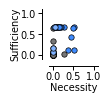

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


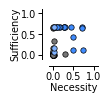

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


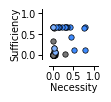

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


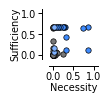

In [63]:
x = {}
y = {}

for key, df in tarsal_sweet_df.items():
    x = df['Necessity'].drop('control')
    y = df['Sufficiency'].drop('control')



    ps = 15
    fig, ax = plt.subplots(1, 1, figsize=(1, 1), constrained_layout=True)

    # 먼저 회색 노드
    for label in x.index:
        if color_info_tarsal_sweet[label] == '#777777':
            ax.scatter(
                x.loc[label], y.loc[label],
                s=ps,
                color=color_info_tarsal_sweet[label],
                edgecolors='black',
                linewidths=0.5,
            )

    # 그 다음 나머지 노드
    for label in x.index:
        if color_info_tarsal_sweet[label] != '#777777':
            ax.scatter(
                x.loc[label], y.loc[label],
                s=ps,
                color=color_info_tarsal_sweet[label],
                edgecolors='black',
                linewidths=0.5,
            )

    ax.set_ylim([-.1, 1.1])
    ax.set_xlim([-.1, 1.1])
    ax.set_yticks(np.arange(0, 1.2, .5))
    ax.set_xticks(np.arange(0, 1.2, .5))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Sufficiency')
    ax.set_xlabel('Necessity')
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.xaxis.labelpad = 0.5
    ax.yaxis.labelpad = 0.5
    ax.tick_params(pad=1)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 두께
    ax.tick_params(
        axis='both',
        width=0.7,      # tick line 두께
        length=3,       # (선택) tick 길이
        pad=1
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )

    LEFT = 0.22
    RIGHT = 0.98
    TOP = 0.95
    BOTTOM = 0.32      # 45도 xtick 기준으로 통일
    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        top=TOP,
        bottom=BOTTOM
    )
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 굵기
    ax.tick_params(
        axis='both',
        width=0.7,
        pad=1
    )
    plt.savefig(f'figures/Necessity_vs_Sufficiency/Tarsal-{key}mM.svg')

/tmp/ipykernel_82363/1627827545.py:67: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

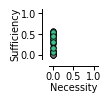

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


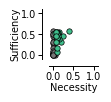

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


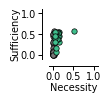

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


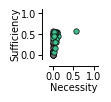

In [65]:
x = {}
y = {}

for key, df in labial_sweet_df.items():
    x = df['Necessity'].drop('control')
    y = df['Sufficiency'].drop('control')



    ps = 15
    fig, ax = plt.subplots(1, 1, figsize=(1, 1), constrained_layout=True)

    # 먼저 회색 노드
    for label in x.index:
        if color_info_labial_sweet[label] == '#777777':
            ax.scatter(
                x.loc[label], y.loc[label],
                s=ps,
                color=color_info_labial_sweet[label],
                edgecolors='black',
                linewidths=0.5,
            )

    # 그 다음 나머지 노드
    for label in x.index:
        if color_info_labial_sweet[label] != '#777777':
            ax.scatter(
                x.loc[label], y.loc[label],
                s=ps,
                color=color_info_labial_sweet[label],
                edgecolors='black',
                linewidths=0.5,
            )

    ax.set_ylim([-.1, 1.1])
    ax.set_xlim([-.1, 1.1])
    ax.set_yticks(np.arange(0, 1.2, .5))
    ax.set_xticks(np.arange(0, 1.2, .5))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Sufficiency')
    ax.set_xlabel('Necessity')
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.xaxis.labelpad = 0.5
    ax.yaxis.labelpad = 0.5
    ax.tick_params(pad=1)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 두께
    ax.tick_params(
        axis='both',
        width=0.7,      # tick line 두께
        length=3,       # (선택) tick 길이
        pad=1
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )

    LEFT = 0.22
    RIGHT = 0.98
    TOP = 0.95
    BOTTOM = 0.32      # 45도 xtick 기준으로 통일
    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        top=TOP,
        bottom=BOTTOM
    )
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 굵기
    ax.tick_params(
        axis='both',
        width=0.7,
        pad=1
    )
    plt.savefig(f'figures/Necessity_vs_Sufficiency/Labellar-{key}mM.svg')

/tmp/ipykernel_82363/3487095241.py:67: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

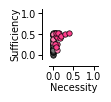

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


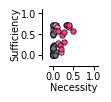

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


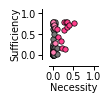

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


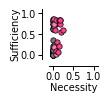

In [73]:
x = {}
y = {}

for key, df in tarsal_geosmin_df.items():
    x = df['Necessity'].drop('control')
    y = df['Sufficiency'].drop('control')



    ps = 15
    fig, ax = plt.subplots(1, 1, figsize=(1, 1), constrained_layout=True)

    # 먼저 회색 노드
    for label in x.index:
        if color_info_tarsal_geosmin[label] == '#777777':
            ax.scatter(
                x.loc[label], y.loc[label],
                s=ps,
                color=color_info_tarsal_geosmin[label],
                edgecolors='black',
                linewidths=0.5,
            )

    # 그 다음 나머지 노드
    for label in x.index:
        if color_info_tarsal_geosmin[label] != '#777777':
            ax.scatter(
                x.loc[label], y.loc[label],
                s=ps,
                color=color_info_tarsal_geosmin[label],
                edgecolors='black',
                linewidths=0.5,
            )

    ax.set_ylim([-.1, 1.1])
    ax.set_xlim([-.1, 1.1])
    ax.set_yticks(np.arange(0, 1.2, .5))
    ax.set_xticks(np.arange(0, 1.2, .5))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Sufficiency')
    ax.set_xlabel('Necessity')
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.xaxis.labelpad = 0.5
    ax.yaxis.labelpad = 0.5
    ax.tick_params(pad=1)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 두께
    ax.tick_params(
        axis='both',
        width=0.7,      # tick line 두께
        length=3,       # (선택) tick 길이
        pad=1
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )

    LEFT = 0.22
    RIGHT = 0.98
    TOP = 0.95
    BOTTOM = 0.32      # 45도 xtick 기준으로 통일
    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        top=TOP,
        bottom=BOTTOM
    )
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 굵기
    ax.tick_params(
        axis='both',
        width=0.7,
        pad=1
    )
    plt.savefig(f'figures/Necessity_vs_Sufficiency/Tarsal_Geosmin-{key}mM.svg')

/tmp/ipykernel_82363/2566873595.py:67: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

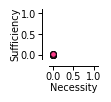

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


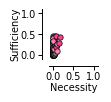

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


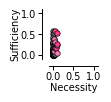

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


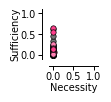

In [74]:
x = {}
y = {}

for key, df in labial_geosmin_df.items():
    x = df['Necessity'].drop('control')
    y = df['Sufficiency'].drop('control')



    ps = 15
    fig, ax = plt.subplots(1, 1, figsize=(1, 1), constrained_layout=True)

    # 먼저 회색 노드
    for label in x.index:
        if color_info_labial_geosmin[label] == '#777777':
            ax.scatter(
                x.loc[label], y.loc[label],
                s=ps,
                color=color_info_labial_geosmin[label],
                edgecolors='black',
                linewidths=0.5,
            )

    # 그 다음 나머지 노드
    for label in x.index:
        if color_info_labial_geosmin[label] != '#777777':
            ax.scatter(
                x.loc[label], y.loc[label],
                s=ps,
                color=color_info_labial_geosmin[label],
                edgecolors='black',
                linewidths=0.5,
            )

    ax.set_ylim([-.1, 1.1])
    ax.set_xlim([-.1, 1.1])
    ax.set_yticks(np.arange(0, 1.2, .5))
    ax.set_xticks(np.arange(0, 1.2, .5))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Sufficiency')
    ax.set_xlabel('Necessity')
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.xaxis.labelpad = 0.5
    ax.yaxis.labelpad = 0.5
    ax.tick_params(pad=1)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 두께
    ax.tick_params(
        axis='both',
        width=0.7,      # tick line 두께
        length=3,       # (선택) tick 길이
        pad=1
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )

    LEFT = 0.22
    RIGHT = 0.98
    TOP = 0.95
    BOTTOM = 0.32      # 45도 xtick 기준으로 통일
    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        top=TOP,
        bottom=BOTTOM
    )
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)

    # tick 굵기
    ax.tick_params(
        axis='both',
        width=0.7,
        pad=1
    )
    plt.savefig(f'figures/Necessity_vs_Sufficiency/Labellar_Geosmin-{key}mM.svg')